# Random Forest Project

For this project we will be exploring publicly available data from [LendingClub.com](https://www.lendingclub.com/). Lending Club connects people who need money (borrowers) with people who have money (investors). We will try to create a model that will help predict whether or not the borrower paid back their loan in full.

We will use lending data from **2007-2010** and classify whether the borrower paid back their loan in full (`not.fully.paid = 0`) or not (`not.fully.paid = 1`).

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Get the Data

In [2]:
loans = pd.read_csv('loan_data.csv')

In [3]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [4]:
loans.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [5]:
loans.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


## Exploratory Data Analysis

Let's do some data visualization using seaborn and pandas built-in plotting capabilities.

**Histogram of FICO score distributions — one for each `credit.policy` outcome**

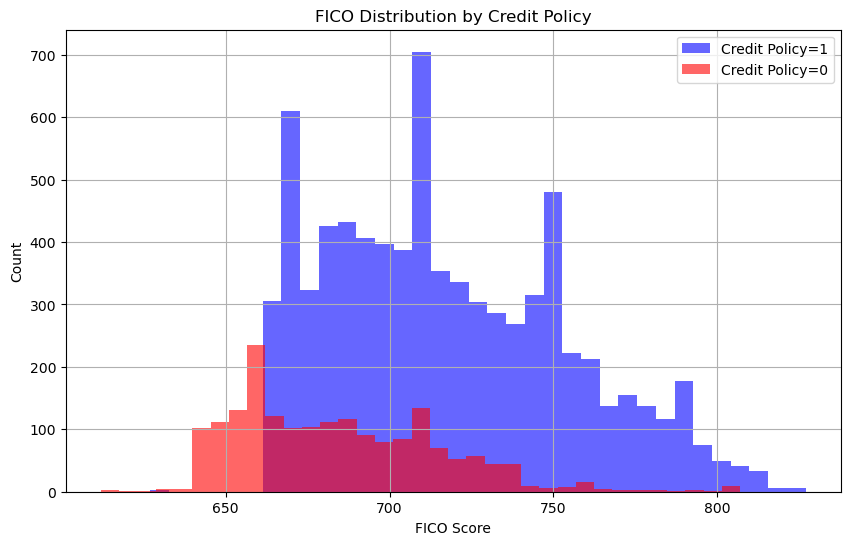

In [6]:
plt.figure(figsize=(10,6))
loans[loans['credit.policy']==1]['fico'].hist(bins=35, color='blue', label='Credit Policy=1', alpha=0.6)
loans[loans['credit.policy']==0]['fico'].hist(bins=35, color='red', label='Credit Policy=0', alpha=0.6)
plt.legend()
plt.xlabel('FICO Score')
plt.ylabel('Count')
plt.title('FICO Distribution by Credit Policy')
plt.show()

**Histogram of FICO score distributions — by `not.fully.paid` outcome**

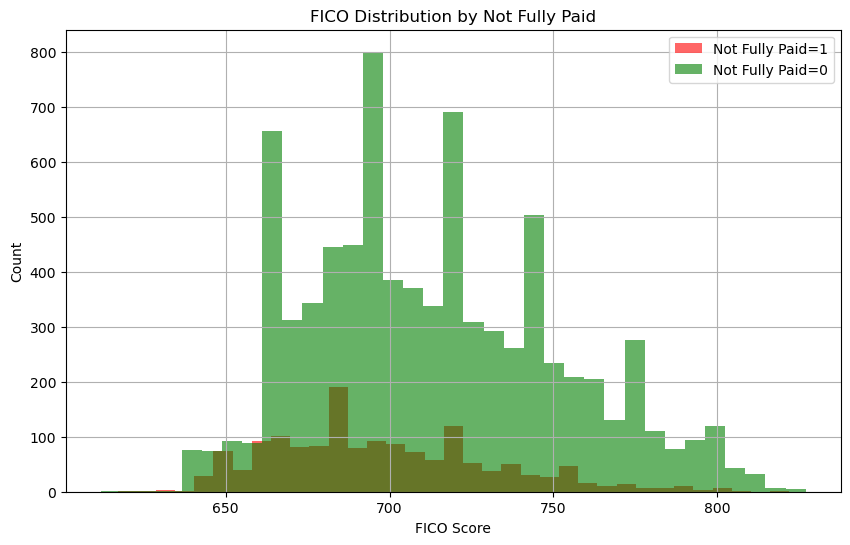

In [7]:
plt.figure(figsize=(10,6))
loans[loans['not.fully.paid']==1]['fico'].hist(bins=35, color='red', label='Not Fully Paid=1', alpha=0.6)
loans[loans['not.fully.paid']==0]['fico'].hist(bins=35, color='green', label='Not Fully Paid=0', alpha=0.6)
plt.legend()
plt.xlabel('FICO Score')
plt.ylabel('Count')
plt.title('FICO Distribution by Not Fully Paid')
plt.show()

**Countplot: loan counts by `purpose`, colored by `not.fully.paid`**

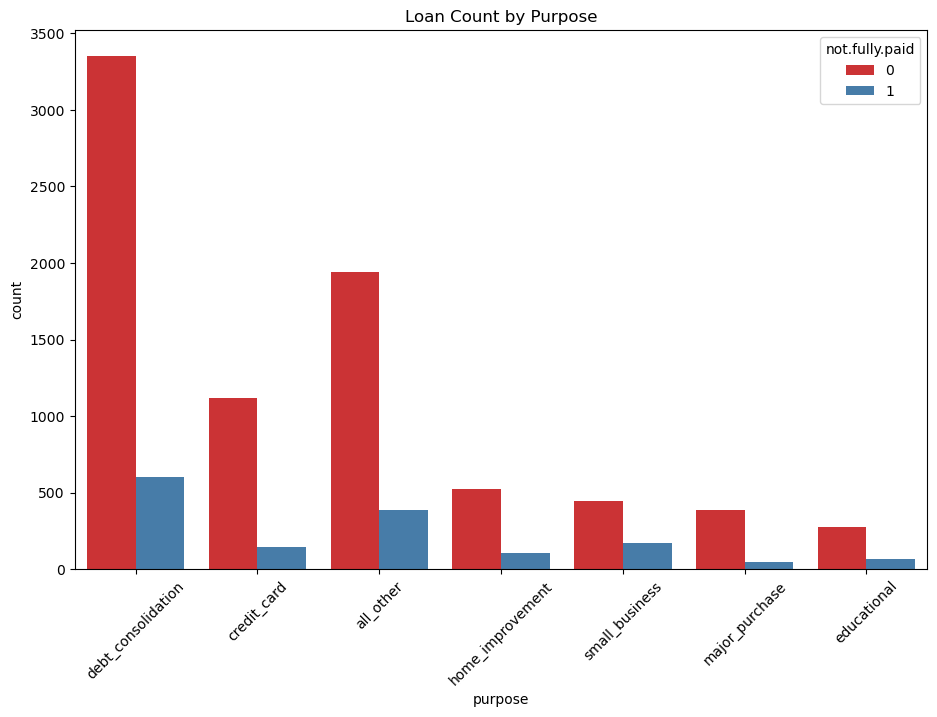

In [8]:
plt.figure(figsize=(11,7))
sns.countplot(x='purpose', hue='not.fully.paid', data=loans, palette='Set1')
plt.title('Loan Count by Purpose')
plt.xticks(rotation=45)
plt.show()

**Jointplot: FICO score vs Interest Rate**

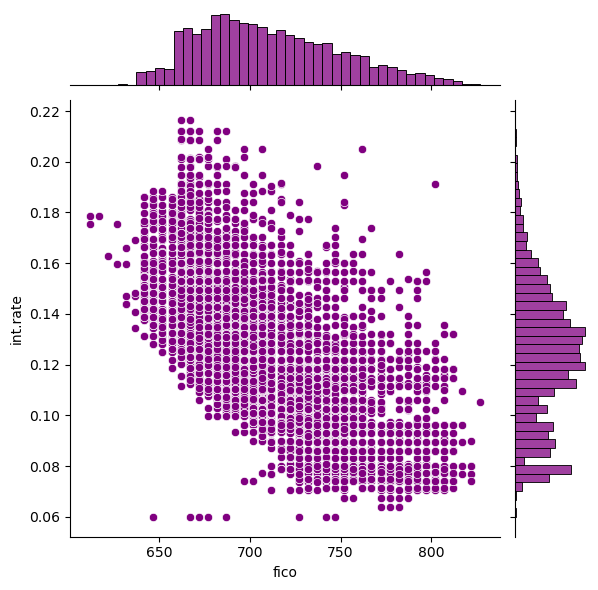

In [9]:
sns.jointplot(x='fico', y='int.rate', data=loans, color='purple')
plt.show()

**lmplot: FICO vs Interest Rate — separated by `not.fully.paid` and `credit.policy`**

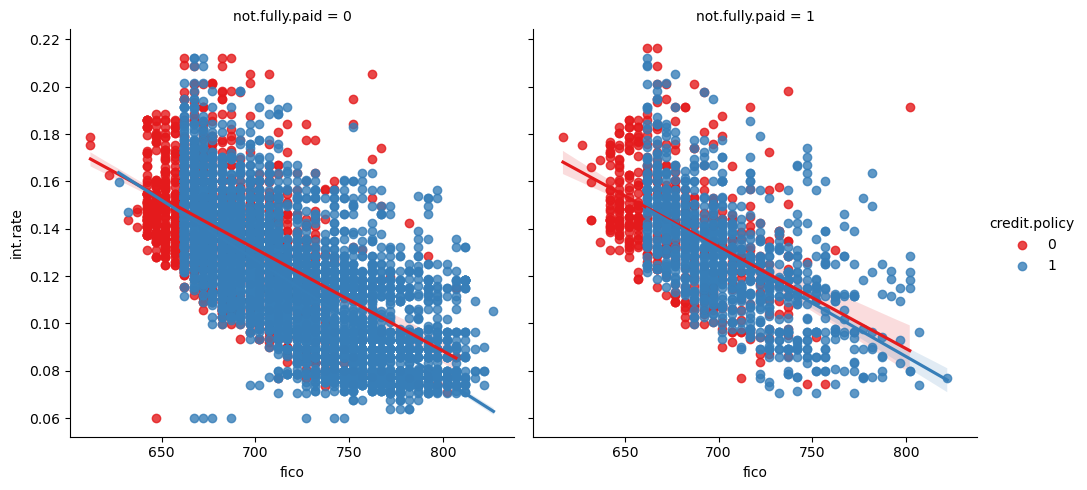

In [10]:
sns.lmplot(x='fico', y='int.rate', data=loans,
           hue='credit.policy', col='not.fully.paid',
           palette='Set1')
plt.show()

## Setting Up the Data

### Handling Categorical Features

The `purpose` column is categorical. We need to convert it to dummy variables so sklearn can work with it.

In [11]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [12]:
cat_feats = ['purpose']

In [13]:
final_data = pd.get_dummies(loans, columns=cat_feats, drop_first=True)
final_data.head()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,False,True,False,False,False,False
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,True,False,False,False,False,False
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,False,True,False,False,False,False
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,False,True,False,False,False,False
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,True,False,False,False,False,False


## Train Test Split

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X = final_data.drop('not.fully.paid', axis=1)
y = final_data['not.fully.paid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101)

## Training a Decision Tree Model

In [16]:
from sklearn.tree import DecisionTreeClassifier

In [17]:
dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Predictions and Evaluation — Decision Tree

In [18]:
predictions = dtree.predict(X_test)

In [19]:
from sklearn.metrics import classification_report, confusion_matrix

print('Classification Report — Decision Tree')
print(classification_report(y_test, predictions))

Classification Report — Decision Tree
              precision    recall  f1-score   support

           0       0.85      0.82      0.83      2431
           1       0.18      0.22      0.20       443

    accuracy                           0.73      2874
   macro avg       0.52      0.52      0.52      2874
weighted avg       0.75      0.73      0.74      2874



In [20]:
print('Confusion Matrix — Decision Tree')
print(confusion_matrix(y_test, predictions))

Confusion Matrix — Decision Tree
[[1986  445]
 [ 345   98]]


## Training the Random Forest Model

In [21]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=600)
rfc.fit(X_train, y_train)

,n_estimators,600
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Predictions and Evaluation — Random Forest

In [22]:
rfc_pred = rfc.predict(X_test)

In [23]:
print('Classification Report — Random Forest')
print(classification_report(y_test, rfc_pred))

Classification Report — Random Forest
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      2431
           1       0.54      0.02      0.03       443

    accuracy                           0.85      2874
   macro avg       0.69      0.51      0.47      2874
weighted avg       0.80      0.85      0.78      2874



In [24]:
print('Confusion Matrix — Random Forest')
print(confusion_matrix(y_test, rfc_pred))

Confusion Matrix — Random Forest
[[2425    6]
 [ 436    7]]


## Conclusion: Which Model Performed Better?

The **Random Forest** model outperforms the Decision Tree overall. 

- The Decision Tree tends to overfit the training data — it memorizes patterns that don't generalize well, which shows up as lower precision/recall on the test set, especially for the minority class (`not.fully.paid = 1`).
- The Random Forest reduces overfitting by averaging predictions across many trees (600 estimators here), leading to better accuracy and more reliable results.
- You may notice a **warning** about low recall for class `1` in both models — this is expected because the dataset is imbalanced (only ~16% of loans were not fully paid). Both models are biased toward predicting class `0`.

**Bottom line:** Random Forest wins due to its ensemble nature reducing variance, at the cost of interpretability compared to a single Decision Tree.